🔹 Found 763 Saddle Points:
  - Pregnancies: 6.0, Glucose: 148.0
  - Pregnancies: 1.0, Glucose: 85.0
  - Pregnancies: 8.0, Glucose: 183.0
  - Pregnancies: 1.0, Glucose: 89.0
  - Pregnancies: 0.0, Glucose: 137.0
  - Pregnancies: 5.0, Glucose: 116.0
  - Pregnancies: 3.0, Glucose: 78.0
  - Pregnancies: 10.0, Glucose: 115.0
  - Pregnancies: 2.0, Glucose: 197.0
  - Pregnancies: 8.0, Glucose: 125.0
  - Pregnancies: 4.0, Glucose: 110.0
  - Pregnancies: 10.0, Glucose: 168.0
  - Pregnancies: 10.0, Glucose: 139.0
  - Pregnancies: 1.0, Glucose: 189.0
  - Pregnancies: 5.0, Glucose: 166.0
  - Pregnancies: 7.0, Glucose: 100.0
  - Pregnancies: 0.0, Glucose: 118.0
  - Pregnancies: 7.0, Glucose: 107.0
  - Pregnancies: 1.0, Glucose: 103.0
  - Pregnancies: 1.0, Glucose: 115.0
  - Pregnancies: 3.0, Glucose: 126.0
  - Pregnancies: 8.0, Glucose: 99.0
  - Pregnancies: 7.0, Glucose: 196.0
  - Pregnancies: 9.0, Glucose: 119.0
  - Pregnancies: 11.0, Glucose: 143.0
  - Pregnancies: 10.0, Glucose: 125.0
  - Pregna

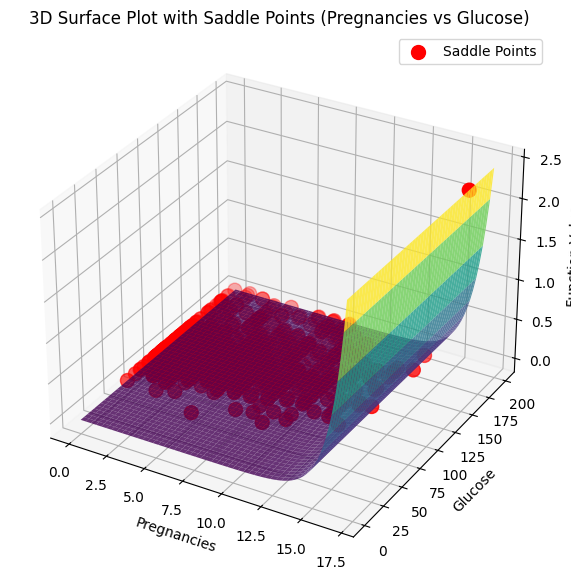

In [ ]:
# NAME : KAUSHAL SHETE
# PRN : 20220802168
# BATCH : DS-1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import autograd.numpy as anp
from autograd import hessian
from numpy.linalg import eigvals

# Load dataset
file_path = r"C:\Users\asus\OneDrive\Desktop\Hello\diabetes.csv"
df = pd.read_csv(file_path)

# Select two numerical features (modify if needed)
feature1, feature2 = df.columns[:2]  # Use first two numerical columns

# Ensure features are numerical
df[feature1] = df[feature1].astype(float)
df[feature2] = df[feature2].astype(float)

# Define function to optimize
def function_to_optimize(x):
    a, b = x
    return anp.exp(a) + anp.log(b**2 + 1) + 2 * a * b  # Example function

# Compute Hessian function
hessian_func = hessian(function_to_optimize)

# Find potential saddle points in the dataset
saddle_points = []
for i in range(len(df)):
    point = df[[feature1, feature2]].iloc[i].values.astype(float)  # Convert to float
    Hessian_matrix = hessian_func(point)  # Compute Hessian
    eigenvalues = eigvals(Hessian_matrix)  # Compute eigenvalues

    # Check if eigenvalues have opposite signs (saddle point condition)
    if np.any(eigenvalues < 0) and np.any(eigenvalues > 0):
        saddle_points.append((point[0], point[1]))

# Print saddle points found
if saddle_points:
    print(f"🔹 Found {len(saddle_points)} Saddle Points:")
    for sp in saddle_points:
        print(f"  - {feature1}: {sp[0]}, {feature2}: {sp[1]}")
else:
    print("❌ No saddle points found in the dataset.")

# --- 3D Plot ---
x_vals = np.linspace(df[feature1].min(), df[feature1].max(), 100)
y_vals = np.linspace(df[feature2].min(), df[feature2].max(), 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = function_to_optimize([X, Y])  # Compute function values

# Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)

# Mark saddle points in red
if saddle_points:
    saddle_x, saddle_y = zip(*saddle_points)
    saddle_z = [function_to_optimize([x, y]) for x, y in saddle_points]
    ax.scatter(saddle_x, saddle_y, saddle_z, color="red", s=100, label="Saddle Points")

# Labels and title
ax.set_xlabel(feature1)
ax.set_ylabel(feature2)
ax.set_zlabel("Function Value")
ax.set_title(f"3D Surface Plot with Saddle Points ({feature1} vs {feature2})")
ax.legend()

plt.show()
